# Lab 4: RNN vs LSTM vs GRU

## Objective
Compare the performance of RNN, LSTM, and GRU on a simple time series prediction task.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
import matplotlib.pyplot as plt
import time

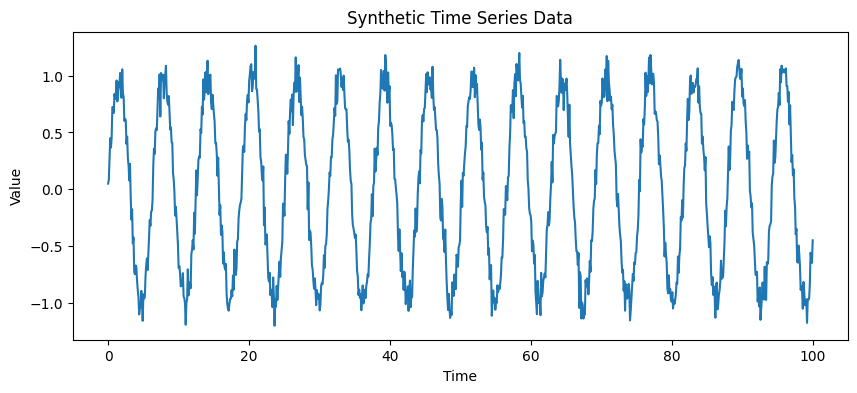

In [3]:
# Generate synthetic time series data
np.random.seed(42)
t = np.linspace(0, 100, 1000)
data = np.sin(t) + 0.1 * np.random.randn(1000)

# Plot the data
plt.figure(figsize=(10, 4))
plt.plot(t, data)
plt.title('Synthetic Time Series Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [5]:
# Preprocess data: create sequences
def create_sequences(data, seq_length):
    X = []
    y = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Reshape for RNN input

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (990, 10, 1), y shape: (990,)


In [7]:
def build_model(model_type):
    model = Sequential()
    
    if model_type == "RNN":
        model.add(SimpleRNN(32, input_shape=(seq_length, 1)))
    elif model_type == "LSTM":
        model.add(LSTM(32, input_shape=(seq_length, 1)))
    elif model_type == "GRU":
        model.add(GRU(32, input_shape=(seq_length, 1)))
    
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    
    return model

In [8]:
# Train RNN
print("Training RNN...")
start_time = time.time()
rnn_model = build_model("RNN")
rnn_history = rnn_model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
rnn_time = time.time() - start_time
rnn_loss = rnn_history.history['val_loss'][-1]
print(f"RNN Training Time: {rnn_time:.2f}s, Final Validation Loss: {rnn_loss:.4f}")

Training RNN...


/Users/prateekrai/Desktop/DL/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN Training Time: 2.28s, Final Validation Loss: 0.0125


In [9]:
# Train LSTM
print("Training LSTM...")
start_time = time.time()
lstm_model = build_model("LSTM")
lstm_history = lstm_model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
lstm_time = time.time() - start_time
lstm_loss = lstm_history.history['val_loss'][-1]
print(f"LSTM Training Time: {lstm_time:.2f}s, Final Validation Loss: {lstm_loss:.4f}")

Training LSTM...
LSTM Training Time: 2.62s, Final Validation Loss: 0.0138


In [10]:
# Train GRU
print("Training GRU...")
start_time = time.time()
gru_model = build_model("GRU")
gru_history = gru_model.fit(X, y, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
gru_time = time.time() - start_time
gru_loss = gru_history.history['val_loss'][-1]
print(f"GRU Training Time: {gru_time:.2f}s, Final Validation Loss: {gru_loss:.4f}")

Training GRU...
GRU Training Time: 3.16s, Final Validation Loss: 0.0132



Comparison Table:
Model	Training Time (s)	Validation Loss
RNN	2.28		0.0125
LSTM	2.62		0.0138
GRU	3.16		0.0132


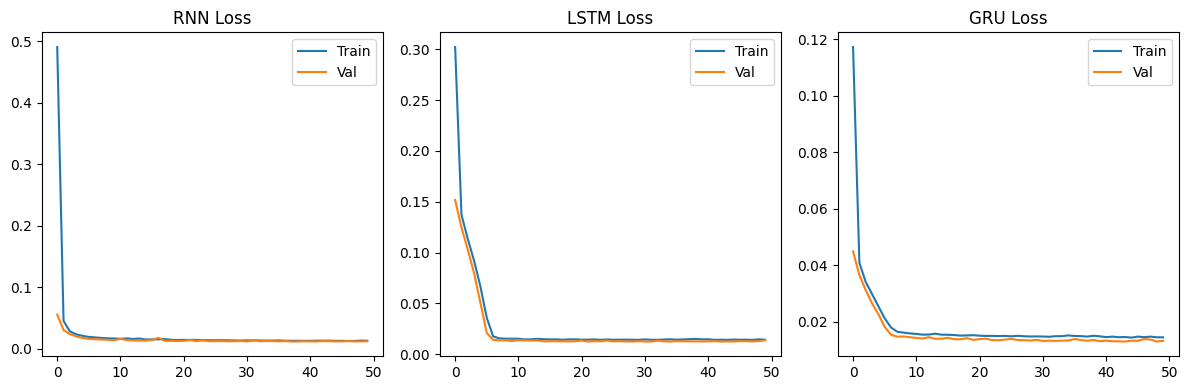

In [12]:
# Compare results
models = ['RNN', 'LSTM', 'GRU']
times = [rnn_time, lstm_time, gru_time]
losses = [rnn_loss, lstm_loss, gru_loss]

print("\nComparison Table:")
print("Model\tTraining Time (s)\tValidation Loss")
for model, t, loss in zip(models, times, losses):
    print(f"{model}\t{t:.2f}\t\t{loss:.4f}")

# Plot training loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(rnn_history.history['loss'], label='Train')
plt.plot(rnn_history.history['val_loss'], label='Val')
plt.title('RNN Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(lstm_history.history['loss'], label='Train')
plt.plot(lstm_history.history['val_loss'], label='Val')
plt.title('LSTM Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(gru_history.history['loss'], label='Train')
plt.plot(gru_history.history['val_loss'], label='Val')
plt.title('GRU Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion

- **RNN**: Fast training but may struggle with long sequences due to vanishing gradients.
- **LSTM**: Better performance on complex sequences but slower training.
- **GRU**: Good balance between performance and speed, often faster than LSTM with similar accuracy.

For real-world applications, LSTM and GRU are preferred over basic RNN for handling long dependencies.